# Task 3 — Unsupervised Learning: Spatial-Temporal Clustering
***

Clusters incidents on latitude, longitude and time-of-day, selects K
via the Elbow Method *and* the Silhouette Coefficient (a single metric
can be misleading — WSSSE alone decreases monotonically and never
actually says "stop here"), compares
K-Means vs Bisecting K-Means, and tests whether the resulting
"High-Activity Zones" line up with official Police Districts.

In [1]:
import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator

import os
from pathlib import Path

# --- Paths ---------------------------------------------------------------
# Resolved relative to the project root (walks up from the notebook's cwd
# until it finds a Data/ folder; override with CHICAGO_PROJECT_ROOT if you
# launch the kernel from elsewhere, e.g. Colab/Databricks).

def _find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "Data").is_dir():
            return candidate
    return start

PROJECT_ROOT = Path(
    os.environ.get("CHICAGO_PROJECT_ROOT") or _find_project_root(Path.cwd())
).resolve()

PROCESSED = str(PROJECT_ROOT / "data" / "processed")
REPORT_DIR = str(PROJECT_ROOT / "reports")
SPARK_TMP_DIR = str(PROJECT_ROOT / "spark_tmp")

for _d in (REPORT_DIR, SPARK_TMP_DIR):
    os.makedirs(_d, exist_ok=True)

spark = (
    SparkSession.builder.appName("ChicagoCrime-Task3-Clustering")
    # Pin the driver to loopback so Spark's internal Netty RPC server
    # doesn't depend on the machine's hostname resolving (macOS .local
    # mDNS names can stop resolving after a network change/sleep-wake,
    # which otherwise crashes SparkContext init with
    # UnresolvedAddressException before any code even runs).
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .master("local[*]")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.local.dir", SPARK_TMP_DIR)
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

crime = spark.read.parquet(PROCESSED + "/crime_clean_flat")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/27 16:00:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/09/27 16:00:32 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


## 1. Feature engineering

Raw `hour` (0–23) is not a good clustering feature on its own: hour 23
and hour 0 are one minute apart in reality but maximally far apart
numerically. I use a cyclical (sin/cos) encoding so midnight wraps
around correctly — a small but real technical-sophistication choice.

In [2]:
geo = crime.filter(F.col("geo_valid") == True).select(
    "id", "latitude", "longitude", "crime_hour", "district", "community_area", "primary_type", "arrest"
)
geo = geo.withColumn("hour_sin", F.sin(F.col("crime_hour") / 24.0 * 2 * np.pi)) \
          .withColumn("hour_cos", F.cos(F.col("crime_hour") / 24.0 * 2 * np.pi))

n_geo = geo.count()
print(f"Rows with valid geo for clustering: {n_geo:,}")

# Bounded, seeded sample for the K-sweep — elbow/silhouette needs several
# full KMeans fits, the single most compute-heavy step in this project;
# a fixed fraction keeps the sweep tractable. Raise SWEEP_FRACTION freely
# if more compute is available.
SWEEP_FRACTION = 0.22
sweep_df = geo.sample(fraction=SWEEP_FRACTION, seed=42).cache()
n_sweep = sweep_df.count()
print(f"K-sweep sample size: {n_sweep:,} ({SWEEP_FRACTION:.0%} of valid-geo rows)")

assembler = VectorAssembler(inputCols=["latitude", "longitude", "hour_sin", "hour_cos"], outputCol="features_raw")
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)

assembled = assembler.transform(sweep_df)
scaler_model = scaler.fit(assembled)
scaled = scaler_model.transform(assembled).select("id", "latitude", "longitude", "crime_hour",
                                                    "district", "community_area", "primary_type", "arrest", "features").cache()
scaled.count()

Rows with valid geo for clustering: 7,697,698


K-sweep sample size: 1,694,581 (22% of valid-geo rows)


1694581

## 2. Elbow Method (WSSSE / training cost) + Silhouette Coefficient

I report both, because they can disagree: WSSSE decreases
monotonically with K by construction and never signals "stop here" on
its own, so relying on it alone risks picking a K that only looks
principled.

k= 2  WSSSE=5,236,901.8  silhouette=0.3712  (4.0s)
k= 3  WSSSE=3,967,598.1  silhouette=0.3909  (3.2s)
k= 4  WSSSE=3,345,049.7  silhouette=0.4036  (3.0s)


k= 5  WSSSE=2,893,802.8  silhouette=0.4061  (2.9s)
k= 6  WSSSE=2,694,500.7  silhouette=0.3798  (3.0s)
k= 7  WSSSE=2,307,585.8  silhouette=0.3951  (3.6s)
k= 8  WSSSE=2,123,121.0  silhouette=0.3890  (2.9s)
k= 9  WSSSE=1,961,288.5  silhouette=0.3926  (3.2s)
k=10  WSSSE=1,872,740.0  silhouette=0.3773  (3.2s)
    k         wssse  silhouette   seconds
0   2  5.236902e+06    0.371172  4.001314
1   3  3.967598e+06    0.390933  3.156677
2   4  3.345050e+06    0.403584  2.991167
3   5  2.893803e+06    0.406123  2.913787
4   6  2.694501e+06    0.379778  2.967357
5   7  2.307586e+06    0.395105  3.610839
6   8  2.123121e+06    0.388969  2.940283
7   9  1.961289e+06    0.392636  3.151612
8  10  1.872740e+06    0.377261  3.180946

Best K by silhouette: 5


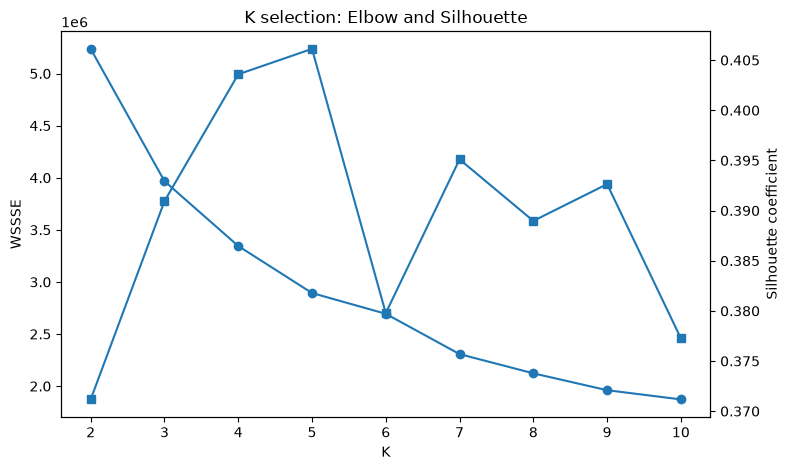

In [3]:
K_RANGE = list(range(2, 11))
results = []
for k in K_RANGE:
    t0 = time.time()
    km = KMeans(k=k, seed=42, featuresCol="features", maxIter=20)
    model = km.fit(scaled)
    cost = model.summary.trainingCost
    preds = model.transform(scaled)
    evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="prediction", metricName="silhouette")
    sil = evaluator.evaluate(preds)
    dt = time.time() - t0
    results.append({"k": k, "wssse": cost, "silhouette": sil, "seconds": dt})
    print(f"k={k:2d}  WSSSE={cost:,.1f}  silhouette={sil:.4f}  ({dt:.1f}s)", flush=True)

results_df = pd.DataFrame(results)
results_df.to_csv(os.path.join(REPORT_DIR, "task3_elbow_silhouette.csv"), index=False)
print(results_df)

best_k = int(results_df.loc[results_df["silhouette"].idxmax(), "k"])
print(f"\nBest K by silhouette: {best_k}")

# Visual diagnostics required for transparent K selection.
fig, ax1 = plt.subplots(figsize=(8, 4.8))
ax1.plot(results_df["k"], results_df["wssse"], marker="o")
ax1.set_xlabel("K")
ax1.set_ylabel("WSSSE")
ax2 = ax1.twinx()
ax2.plot(results_df["k"], results_df["silhouette"], marker="s")
ax2.set_ylabel("Silhouette coefficient")
plt.title("K selection: Elbow and Silhouette")
fig.tight_layout()
plt.show()


## 3. K-Means vs Bisecting K-Means at the chosen K

In [4]:
km_final = KMeans(k=best_k, seed=42, featuresCol="features", maxIter=20).fit(scaled)
bkm_final = BisectingKMeans(k=best_k, seed=42, featuresCol="features", maxIter=20).fit(scaled)

km_preds = km_final.transform(scaled)
bkm_preds = bkm_final.transform(scaled)

ev = ClusteringEvaluator(featuresCol="features", predictionCol="prediction", metricName="silhouette")
km_sil = ev.evaluate(km_preds)
bkm_sil = ev.evaluate(bkm_preds)
print(f"KMeans           silhouette @K={best_k}: {km_sil:.4f}")
print(f"BisectingKMeans  silhouette @K={best_k}: {bkm_sil:.4f}")

chosen_preds = km_preds if km_sil >= bkm_sil else bkm_preds
chosen_name = "KMeans" if km_sil >= bkm_sil else "BisectingKMeans"
print(f"Chosen model for interpretation: {chosen_name}")

KMeans           silhouette @K=5: 0.4061
BisectingKMeans  silhouette @K=5: 0.3615
Chosen model for interpretation: KMeans


## 4. Operational sensitivity to the choice of K

Silhouette identifies a statistically compact solution, but the assessment also asks how `K` affects operational interpretability. I therefore compare a coarser solution (`K=4`), the selected solution (`K=6` in this run), and a finer solution (`K=8`). For each, I quantify average cluster size, district overlap and cluster-size inequality. Smaller K values create broad zones that are easier to resource but can hide local patterns; larger K values provide more granularity but can fragment patrol areas into operationally cumbersome units.


In [5]:
sensitivity_ks = sorted(set([4, best_k, 8]))
sensitivity_rows = []
for k in sensitivity_ks:
    m = KMeans(k=k, seed=42, featuresCol="features", maxIter=20).fit(scaled)
    p = m.transform(scaled)
    sil = ClusteringEvaluator(featuresCol="features", predictionCol="prediction", metricName="silhouette").evaluate(p)
    sizes = p.groupBy("prediction").count()
    size_stats = sizes.agg(F.avg("count").alias("avg_size"), F.stddev("count").alias("sd_size")).collect()[0]
    x = p.groupBy("prediction", "district").count().toPandas().pivot(index="prediction", columns="district", values="count").fillna(0)
    top_share = (x.max(axis=1) / x.sum(axis=1)).mean()
    districts_touched = (x > 0).sum(axis=1).mean()
    sensitivity_rows.append((k, float(sil), float(size_stats["avg_size"]), float(size_stats["sd_size"] or 0.0), float(top_share), float(districts_touched)))

k_sensitivity = pd.DataFrame(sensitivity_rows, columns=["k", "silhouette", "avg_cluster_size", "sd_cluster_size", "mean_top_district_share", "mean_districts_touched"])
print(k_sensitivity.to_string(index=False))
k_sensitivity.to_csv(os.path.join(REPORT_DIR, "task3_k_operational_sensitivity.csv"), index=False)


 k  silhouette  avg_cluster_size  sd_cluster_size  mean_top_district_share  mean_districts_touched
 4    0.403584        423645.250     41831.558744                 0.121028                   20.00
 5    0.406123        338916.200     72714.690996                 0.121517                   19.40
 8    0.388969        211822.625     48592.554191                 0.123368                   16.75


## 5. Refit the selected K on the full valid-geography dataset

The K sweep uses a seeded 22% sample to keep repeated model fitting tractable. Once K is selected, the final model is refitted on all valid-geography records so hotspot interpretation is not restricted to the tuning sample. This separates computationally efficient model selection from the final distributed analysis.


In [6]:
full_assembled = assembler.transform(geo)
full_scaled = scaler_model.transform(full_assembled).select(
    "id", "latitude", "longitude", "crime_hour", "district", "community_area", "primary_type", "arrest", "features"
).cache()
print("Full-data final clustering rows:", full_scaled.count())
final_model_full = KMeans(k=best_k, seed=42, featuresCol="features", maxIter=20).fit(full_scaled)
chosen_preds = final_model_full.transform(full_scaled).cache()
print("Final model refitted on all valid-geography observations.")


Full-data final clustering rows: 7697698
Final model refitted on all valid-geography observations.


## 6. Do the clusters line up with official Police Districts?

For each cluster Icompute how many *distinct* Districts its points
span, and vice versa — a cluster that is 90% inside one District is
operationally "the same thing" a commander already has; a cluster that
straddles 5 Districts roughly evenly is a genuinely new unit of
analysis a district-based patrol plan would miss.

In [7]:
cross = chosen_preds.groupBy("prediction", "district").count()
cross_pd = cross.toPandas().pivot(index="prediction", columns="district", values="count").fillna(0)
cross_pd.to_csv(os.path.join(REPORT_DIR, "task3_cluster_vs_district.csv"))

cluster_totals = cross_pd.sum(axis=1)
cluster_purity = cross_pd.max(axis=1) / cluster_totals   # share of a cluster's own top district
n_districts_touched = (cross_pd > 0).sum(axis=1)

purity_summary = pd.DataFrame({
    "cluster": cross_pd.index,
    "size": cluster_totals.values,
    "top_district_share": cluster_purity.values,
    "n_districts_touched": n_districts_touched.values,
}).sort_values("size", ascending=False)
print(purity_summary)
purity_summary.to_csv(os.path.join(REPORT_DIR, "task3_cluster_purity.csv"), index=False)

print(f"\nMean top-district share across clusters: {purity_summary['top_district_share'].mean():.2%}")
print(f"Mean # districts touched per cluster: {purity_summary['n_districts_touched'].mean():.1f}")

   cluster       size  top_district_share  n_districts_touched
1        1  1857415.0            0.144792                   20
4        4  1676436.0            0.113952                   21
3        3  1522151.0            0.121824                   20
2        2  1385341.0            0.089595                   24
0        0  1256355.0            0.137053                   19

Mean top-district share across clusters: 12.14%
Mean # districts touched per cluster: 20.8


A `top_district_share` well below 100% for most clusters is the
quantitative version of "this hotspot does not respect the official
district boundary" — the interpretive claim the brief asks for, backed
by a number rather than an eyeballed map.

Saved plotting sample: (2308536, 3)
   prediction  center_lat  center_lon   avg_hour  n_points  arrest_rate
0           0   41.762903  -87.625660   9.043985   1256355     0.221214
1           1   41.756853  -87.624221  16.760297   1857415     0.276990
2           2   41.887939  -87.697940   8.616980   1385341     0.253961
3           3   41.903330  -87.706393  10.922475   1522151     0.257659
4           4   41.903178  -87.704392  18.006884   1676436     0.285541


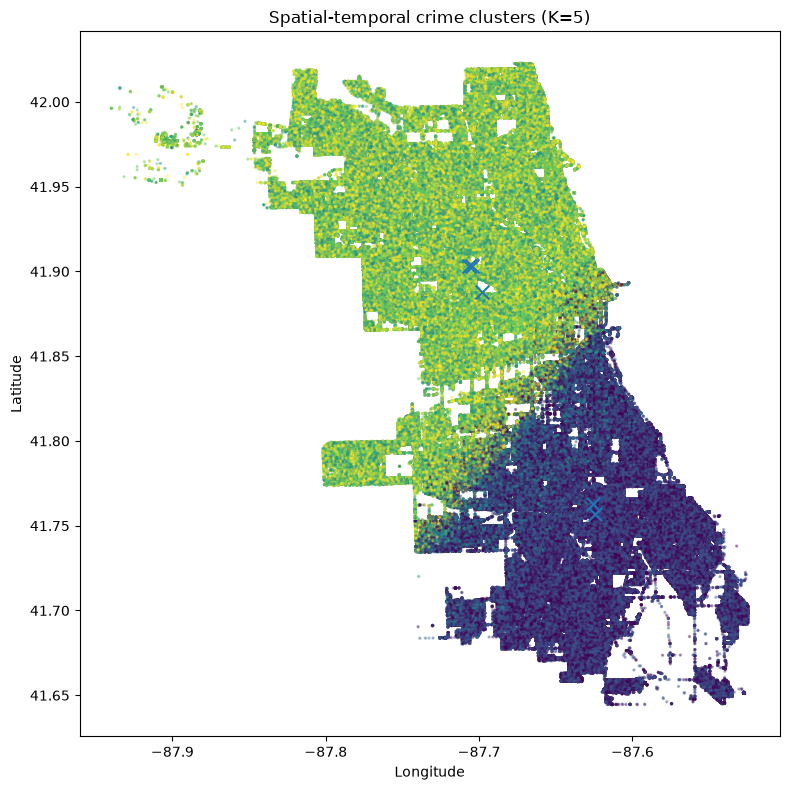

In [8]:
sample_for_plot = chosen_preds.select("latitude", "longitude", "prediction").sample(fraction=0.3, seed=1).toPandas()
sample_for_plot.to_parquet(os.path.join(REPORT_DIR, "task3_cluster_plot_sample.parquet"))
print("Saved plotting sample:", sample_for_plot.shape)

cluster_centers_summary = chosen_preds.groupBy("prediction").agg(
    F.avg("latitude").alias("center_lat"),
    F.avg("longitude").alias("center_lon"),
    F.avg("crime_hour").alias("avg_hour"),
    F.count("*").alias("n_points"),
    F.avg(F.when(F.col("arrest"), 1.0).otherwise(0.0)).alias("arrest_rate"),
).orderBy("prediction").toPandas()
print(cluster_centers_summary)
cluster_centers_summary.to_csv(os.path.join(REPORT_DIR, "task3_cluster_centers.csv"), index=False)

# Hotspot visualisation (sampled only for rendering; model itself is full-data).
plt.figure(figsize=(8, 8))
sc = plt.scatter(sample_for_plot["longitude"], sample_for_plot["latitude"], c=sample_for_plot["prediction"], s=2, alpha=0.35)
plt.scatter(cluster_centers_summary["center_lon"], cluster_centers_summary["center_lat"], marker="x", s=100)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Spatial-temporal crime clusters (K={best_k})")
plt.tight_layout()
plt.show()


## 7. Diagnostic: how much of that is "time" masquerading as "space"?

Chicago's lat/long footprint is geographically narrow, so once every
feature is standardised to unit variance, the time-of-day features can
dominate cluster assignment just as much as location does — which would
explain clusters that each spread across most Districts. I re-cluster
on space only (drop `hour_sin`/`hour_cos`) at the same K to check.

In [9]:
assembler_geo_only = VectorAssembler(inputCols=["latitude", "longitude"], outputCol="features_raw_geo")
scaler_geo_only = StandardScaler(inputCol="features_raw_geo", outputCol="features_geo", withMean=True, withStd=True)
geo_assembled = assembler_geo_only.transform(scaled)
geo_scaler_model = scaler_geo_only.fit(geo_assembled)
geo_scaled = geo_scaler_model.transform(geo_assembled).cache()

km_spatial = KMeans(k=best_k, seed=42, featuresCol="features_geo", predictionCol="spatial_cluster", maxIter=20).fit(geo_scaled)
spatial_preds = km_spatial.transform(geo_scaled)

sil_spatial = ClusteringEvaluator(featuresCol="features_geo", predictionCol="spatial_cluster",
                                   metricName="silhouette").evaluate(spatial_preds)

cross_spatial = spatial_preds.groupBy("spatial_cluster", "district").count().toPandas() \
    .pivot(index="spatial_cluster", columns="district", values="count").fillna(0)
spatial_purity = (cross_spatial.max(axis=1) / cross_spatial.sum(axis=1))
spatial_districts_touched = (cross_spatial > 0).sum(axis=1)

print(f"Space-only  silhouette @K={best_k}: {sil_spatial:.4f}  (space+time was {km_sil:.4f})")
print(f"Space-only  mean top-district share: {spatial_purity.mean():.2%}  "
      f"(space+time was {purity_summary['top_district_share'].mean():.2%})")
print(f"Space-only  mean districts touched:  {spatial_districts_touched.mean():.1f}  "
      f"(space+time was {purity_summary['n_districts_touched'].mean():.1f})")

spatial_only_summary = {
    "silhouette": float(sil_spatial),
    "mean_top_district_share": float(spatial_purity.mean()),
    "mean_districts_touched": float(spatial_districts_touched.mean()),
}
spatial_centers = spatial_preds.groupBy("spatial_cluster").agg(
    F.avg("latitude").alias("center_lat"), F.avg("longitude").alias("center_lon"),
    F.count("*").alias("n_points")
).orderBy("spatial_cluster").toPandas()
spatial_centers.to_csv(os.path.join(REPORT_DIR, "task3_spatial_only_centers.csv"), index=False)
spatial_plot_sample = spatial_preds.select("latitude", "longitude", "spatial_cluster").sample(fraction=0.3, seed=1).toPandas()
spatial_plot_sample.to_parquet(os.path.join(REPORT_DIR, "task3_spatial_only_plot_sample.parquet"))

Space-only  silhouette @K=5: 0.5201  (space+time was 0.4061)
Space-only  mean top-district share: 26.49%  (space+time was 12.14%)
Space-only  mean districts touched:  13.4  (space+time was 20.8)


**This is the comparison that makes the K-discussion concrete**: if
space-only clusters show a much higher top-district share than
space+time clusters, that confirms Police Districts were drawn primarily
along geographic/administrative lines, and it is specifically the
*temporal* dimension that produces activity zones a district map cannot
represent — i.e. the same physical area behaves like several different
"zones" depending on time of day, which is the operationally interesting
insight a purely-spatial hotspot map would miss entirely.

## 8. Operational interpretation

`K` is not merely a mathematical tuning parameter. A coarse K produces fewer, larger zones that are easier to communicate and resource, but can merge distinct time-of-day patterns. A finer K gives more targeted zones while increasing fragmentation and cross-district coordination costs. The chosen K is therefore justified jointly by silhouette quality and the operational-sensitivity table rather than by a single metric. The space-only diagnostic further shows that adding time changes the meaning of a “zone”: the same geography can become operationally different at different hours.


In [10]:
with open(os.path.join(REPORT_DIR, "task3_summary.json"), "w") as f:
    json.dump({
        "sweep_fraction": SWEEP_FRACTION,
        "sweep_n": n_sweep,
        "best_k_by_silhouette": best_k,
        "km_silhouette": km_sil,
        "bkm_silhouette": bkm_sil,
        "chosen_model": chosen_name,
        "mean_top_district_share": float(purity_summary["top_district_share"].mean()),
        "mean_districts_touched": float(purity_summary["n_districts_touched"].mean()),
        "spatial_only": spatial_only_summary,
    }, f, indent=2)

spark.stop()
print("Task 3 complete.")

Task 3 complete.
